## Anomaly Detection with NVIDIA RAPIDS AI

### Project Overview

This project demonstrates how machine learning can enhance the monitoring of complex systems, specifically data centers.

**What we're doing:**
We're creating **synthetic data** that mimics sensor readings from a data center (e.g., CPU utilization, temperature, network latency).

**Why it's crucial for data centers:**
Data centers require continuous, proactive monitoring. Identifying **anomalies** – unusual patterns in sensor data – is vital. These anomalies can signal critical issues like impending hardware failures, overheating, network bottlenecks, or security breaches. Early detection prevents downtime, optimizes resource allocation, and ensures operational stability.

**How we're doing it:**
We leverage **NVIDIA's RAPIDS AI tools (`cuML` and `cuDF`)** for GPU-accelerated analysis. Using **K-Means Clustering**, we group similar sensor readings. Readings significantly distant from any cluster centroid are flagged as potential anomalies.

**The Goal:**
To showcase an automated approach to detecting critical system deviations, a skill invaluable for maintaining robust and efficient data center operations.

## Anomaly Detection in Synthetic Data Center Sensor Data with NVIDIA cuML

This project demonstrates how to generate synthetic data center sensor readings and use NVIDIA cuML for GPU-accelerated anomaly detection. We'll simulate common sensor metrics and then identify unusual patterns that might indicate issues.

In [7]:
# --- Step 1: Install RAPIDS AI Libraries (cuDF and cuML) ---
# This step installs the necessary libraries for GPU-accelerated data processing and machine learning.
# It might take a few minutes and require a Colab runtime restart after execution.

# Check if we're running on a GPU runtime
import os
if not os.environ.get('COLAB_GPU', False):
    print("WARNING: This notebook is designed to run on a GPU runtime. Please go to Runtime -> Change runtime type and select 'GPU' for optimal performance.")

# Install RAPIDS Colab package - simplifies setting up cuDF and cuML
!pip install -q condacolab
import condacolab
condacolab.install()

# Install cuDF and cuML using conda (this can take several minutes)
# Attempting to let conda resolve Python and CUDA versions for cuml=24.02
!conda install -c rapidsai -c conda-forge -c nvidia cudf cuml=24.02 -y

print("RAPIDS AI libraries installed. Please RESTART YOUR COLAB RUNTIME (Runtime -> Restart runtime) after this cell finishes if prompted, then re-run the cells from the beginning.")

✨🍰✨ Everything looks OK!
Channels:
 - rapidsai
 - conda-forge
 - nvidia
Platform: linux-64
Solving environment: | / - warning  libmamba Added empty dependency for problem type SOLVER_RULE_UPDATE
\ | / - \ | / failed

LibMambaUnsatisfiableError: Encountered problems while solving:
  - nothing provides requested cudatoolkit 12.0**
  - package cuml-24.02.00-cuda11_py310_240213_geb50e481d_0 requires python >=3.10,<3.11.0a0, but none of the providers can be installed

Could not solve for environment specs
The following packages are incompatible
├─ cudatoolkit 12.0**  does not exist (perhaps a typo or a missing channel);
├─ cuml 24.02**  is installable with the potential options
│  ├─ cuml 24.02.00 would require
│  │  └─ python >=3.10,<3.11.0a0 , which can be installed;
│  └─ cuml 24.02.00 would require
│     └─ python >=3.9,<3.10.0a0 , which can be installed;
└─ pin-1 is not installable because it requires
   └─ python 3.12** , which conflicts with any installable versio

### After restarting the runtime, re-run all cells from the beginning. Then proceed with data generation and anomaly detection.

In [2]:
# --- Step 2: Generate Synthetic Data Center Sensor Readings ---
# We'll create a synthetic dataset representing various sensor metrics over time.

import pandas as pd
import numpy as np
import datetime

# Set a random seed for reproducibility
np.random.seed(42)

num_records = 1000
start_time = datetime.datetime(2023, 1, 1, 0, 0, 0)

time_stamps = [start_time + datetime.timedelta(minutes=i) for i in range(num_records)]

# Normal operating conditions
cpu_usage = np.random.normal(loc=50, scale=5, size=num_records)
memory_usage = np.random.normal(loc=60, scale=8, size=num_records)
temperature = np.random.normal(loc=25, scale=2, size=num_records)
network_latency = np.random.normal(loc=10, scale=1, size=num_records)

# Introduce some anomalies:
# 1. High CPU spike
cpu_usage[200:210] = np.random.normal(loc=95, scale=3, size=10)
# 2. Memory leak/surge
memory_usage[450:460] = np.random.normal(loc=90, scale=5, size=10)
# 3. Temperature increase
temperature[700:715] = np.random.normal(loc=35, scale=2, size=15)
# 4. Network latency spike
network_latency[850:855] = np.random.normal(loc=50, scale=5, size=5)

# Combine into a Pandas DataFrame
data_df = pd.DataFrame({
    'timestamp': time_stamps,
    'cpu_usage': cpu_usage,
    'memory_usage': memory_usage,
    'temperature': temperature,
    'network_latency': network_latency
})

print("Synthetic data generated successfully:")
display(data_df.head())
display(data_df.describe())


Synthetic data generated successfully:


,timestamp,cpu_usage,memory_usage,temperature,network_latency
0,2023-01-01 00:00:00,52.483571,71.194843,23.649643,8.092192
1,2023-01-01 00:01:00,49.308678,67.397069,24.710963,9.139615
2,2023-01-01 00:02:00,53.238443,60.477043,23.415160,9.586394
3,2023-01-01 00:03:00,57.615149,54.824506,24.384077,11.887688
4,2023-01-01 00:04:00,48.829233,65.585787,21.212771,10.556553


,timestamp,cpu_usage,memory_usage,temperature,network_latency
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2023-01-01 08:19:29.999999744,50.502875,60.796555,25.136301,10.184193
min,2023-01-01 00:00:00,33.793663,36.476891,18.960976,7.070551
25%,2023-01-01 04:09:45,46.802075,55.154877,23.723295,9.264330
50%,2023-01-01 08:19:30,50.138011,60.525861,25.004581,10.010190
75%,2023-01-01 12:29:15,53.320081,65.948585,26.359168,10.683319
max,2023-01-01 16:39:00,96.899980,93.480840,39.339873,54.783516
std,NaN,6.510956,8.395368,2.277928,3.047153


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [3]:
# --- Step 3: Convert to cuDF DataFrame and Prepare for cuML ---
# cuML models work with cuDF DataFrames for GPU acceleration.

import cudf
from cuml.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select the features for anomaly detection (numerical sensor readings)
features = ['cpu_usage', 'memory_usage', 'temperature', 'network_latency']
X_cpu = data_df[features]

# Scale the features to ensure all metrics contribute equally to distance calculations
scaler = StandardScaler()
X_scaled_cpu = scaler.fit_transform(X_cpu)

# Convert scaled data to cuDF DataFrame
X_gpu = cudf.DataFrame(X_scaled_cpu, columns=features)

print("Data converted to cuDF and scaled. Ready for cuML:")
display(X_gpu.head())


Data converted to cuDF and scaled. Ready for cuML:


,cpu_usage,memory_usage,temperature,network_latency
0,0.304362,1.239194,-0.652962,-0.686886
1,-0.183505,0.786602,-0.186815,-0.342976
2,0.420359,-0.038077,-0.755951,-0.196281
3,1.092901,-0.711706,-0.330388,0.559324
4,-0.257179,0.570747,-1.723274,0.122260


In [4]:
# --- Step 4: Perform Anomaly Detection using cuML KMeans ---
# We'll use KMeans clustering. Anomalies will be data points far from their assigned cluster centroid.

# Define the number of clusters. For anomaly detection, often a small number of clusters works well
# where 'normal' data forms tight clusters and anomalies are outliers.
# Let's start with 3 clusters.
n_clusters = 3

kmeans_gpu = KMeans(n_clusters=n_clusters, random_state=42, output_type='cudf')
kmeans_gpu.fit(X_gpu)

# Get cluster assignments for each data point
clusters_gpu = kmeans_gpu.labels_

# Calculate distances from each point to its assigned cluster centroid
distances_gpu = kmeans_gpu.transform(X_gpu)
min_distances_gpu = cudf.DataFrame(distances_gpu.min(axis=1))

# Add cluster labels and min distances back to the original (CPU) DataFrame for easier analysis
data_df['cluster'] = clusters_gpu.to_pandas()
data_df['min_distance'] = min_distances_gpu.to_pandas()

# Define an anomaly threshold. This often requires some experimentation.
# A common approach is to use a percentile of the distances.
# Let's say, points with distances in the top 5% are anomalies.
anomaly_threshold = data_df['min_distance'].quantile(0.95)
data_df['is_anomaly'] = data_df['min_distance'] > anomaly_threshold

print(f"Anomaly detection complete. Using a threshold of {anomaly_threshold:.4f} (top 5% of distances).")
print(f"Detected {data_df['is_anomaly'].sum()} anomalies.")
display(data_df[data_df['is_anomaly']].head())


Anomaly detection complete. Using a threshold of 5.7480 (top 5% of distances).
Detected 50 anomalies.


,timestamp,cpu_usage,memory_usage,temperature,network_latency,cluster,min_distance,is_anomaly
24,2023-01-01 00:24:00,47.278086,73.820345,18.960976,8.130258,2,9.292653,True
35,2023-01-01 00:35:00,43.895782,72.591894,30.519320,10.446873,2,6.076786,True
83,2023-01-01 01:23:00,47.408649,76.613984,20.407638,8.882814,2,6.531285,True
200,2023-01-01 03:20:00,92.409519,61.001796,28.608696,10.185176,0,40.977478,True
201,2023-01-01 03:21:00,94.906390,56.564756,24.618192,10.425445,0,42.439874,True


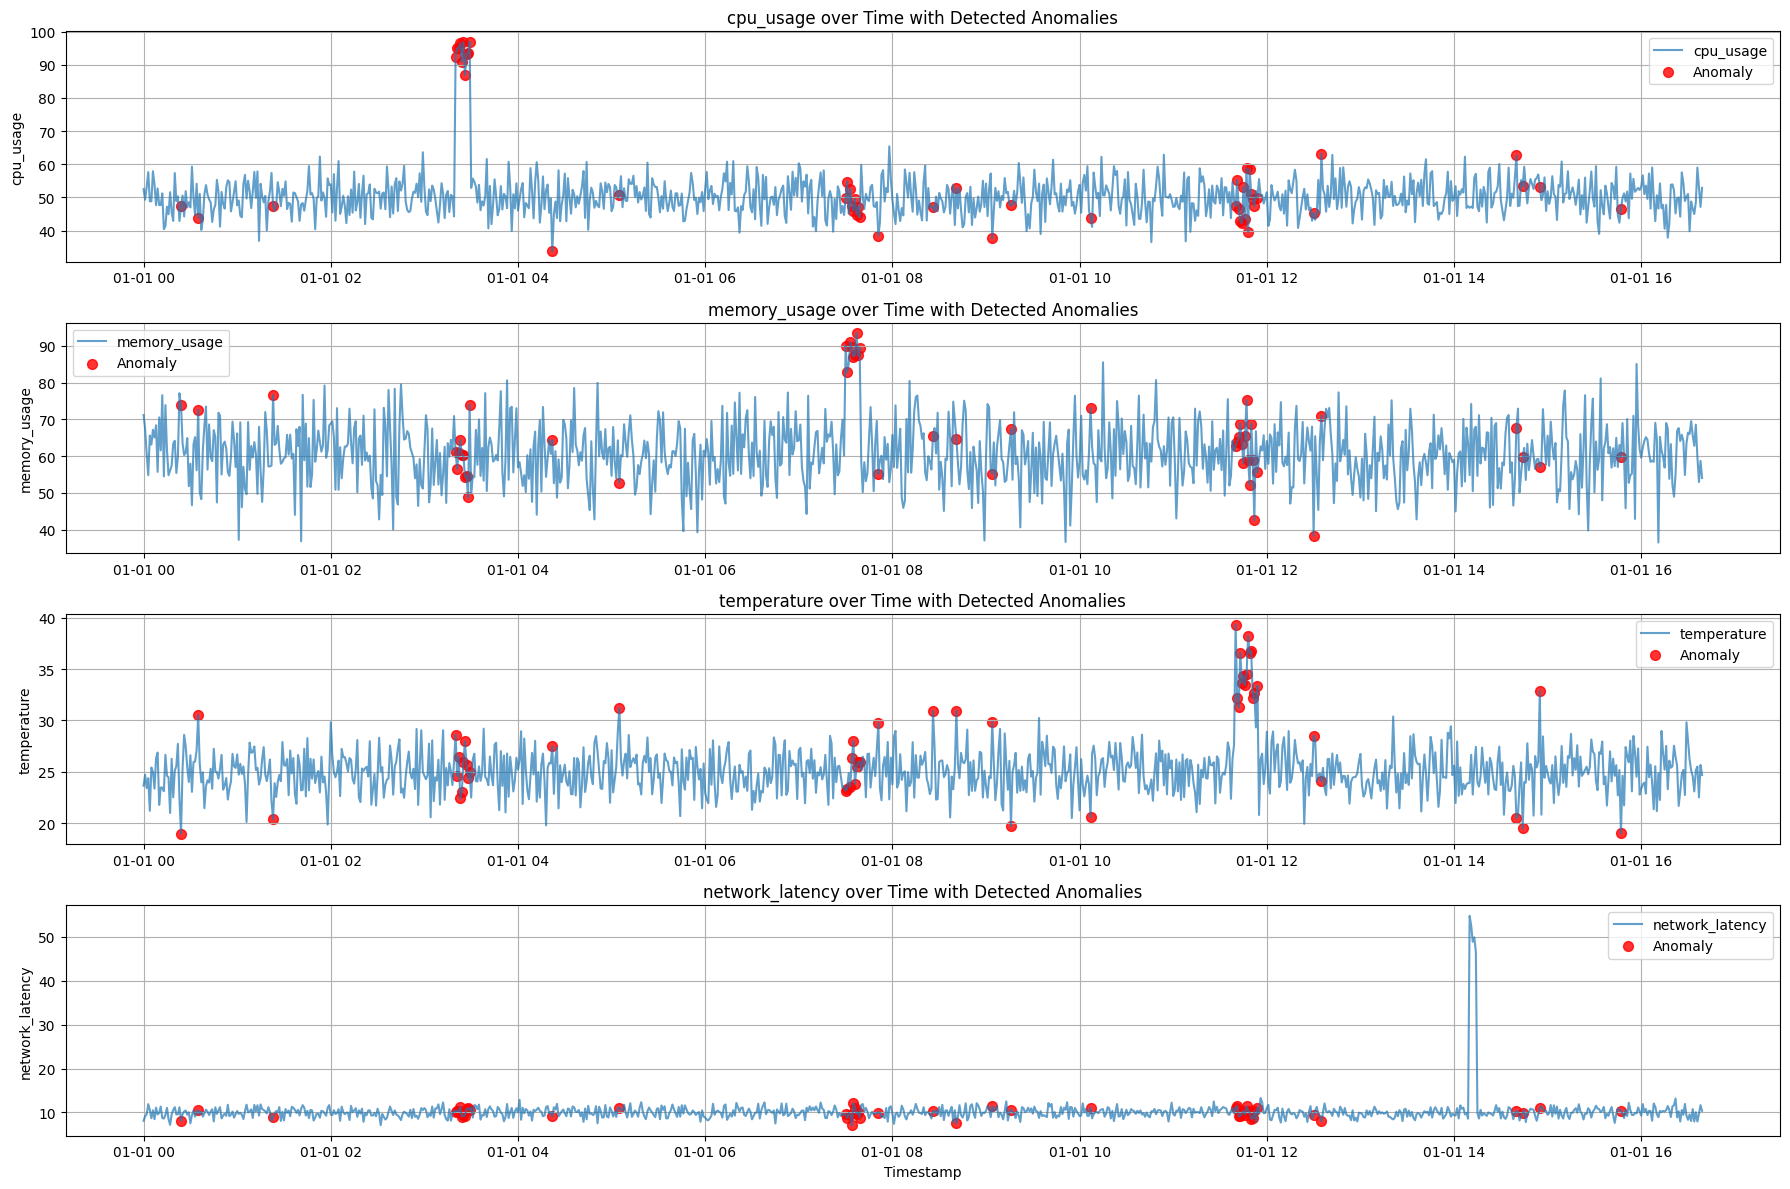


Insights:
The plots above show the sensor readings over time. Red circles indicate points identified as anomalies by the cuML KMeans model.
You can observe how the anomalies often correspond to the spikes or unusual shifts we introduced in the synthetic data.
This framework can be extended to real data center logs for proactive maintenance and operational insights.


In [5]:
# --- Step 5: Visualize the Results ---
# Plot the sensor data and highlight the detected anomalies.

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))

sensor_metrics = ['cpu_usage', 'memory_usage', 'temperature', 'network_latency']

for i, metric in enumerate(sensor_metrics):
    plt.subplot(len(sensor_metrics), 1, i + 1)
    plt.plot(data_df['timestamp'], data_df[metric], label=metric, alpha=0.7)

    # Plot anomalies
    anomalies = data_df[data_df['is_anomaly']]
    plt.scatter(anomalies['timestamp'], anomalies[metric],
                color='red', s=50, marker='o', label='Anomaly', alpha=0.8)

    plt.title(f'{metric} over Time with Detected Anomalies')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)

plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()

print("\nInsights:")
print("The plots above show the sensor readings over time. Red circles indicate points identified as anomalies by the cuML KMeans model.")
print("You can observe how the anomalies often correspond to the spikes or unusual shifts we introduced in the synthetic data.")
print("This framework can be extended to real data center logs for proactive maintenance and operational insights.")

Each plot shows one of the synthetic sensor metrics (CPU usage, Memory usage, Temperature, and Network Latency) over time. The blue line represents the normal fluctuations and trends of that sensor metric.

Key Interpretation Points:
Red Circles: Detected Anomalies

The most important feature are the red circles scattered across the blue lines. These circles indicate the data points that the cuML KMeans model identified as anomalies based on their distance from the established clusters of 'normal' behavior.
Notice how these red circles often coincide with spikes, sudden drops, or prolonged shifts in the blue sensor data line. This is exactly what we would expect, as we deliberately introduced these unusual patterns into the synthetic data.
Specific Anomalies Introduced:

For example, in the 'cpu_usage' plot, you'll likely see red circles around the spike where CPU usage was artificially increased (around the 200-210 minute mark in your synthetic data generation).
Similarly, for 'memory_usage', you should see anomalies highlighting the memory surge (around the 450-460 minute mark).
The 'temperature' plot will show anomalies during the temperature increase (around 700-715 minutes).
And the 'network_latency' plot will highlight the network latency spike (around 850-855 minutes).
Overall Insight:
These plots visually confirm that the cuML KMeans model effectively detected the anomalies we introduced into the synthetic data. In a real-world scenario, this kind of visualization would be crucial for a data center operator to quickly identify when and where unusual activity is occurring, allowing for proactive investigation and maintenance. The ability to do this with GPU acceleration makes it feasible for very large and fast-moving datasets.

## Project Learnings and Summary

This project successfully demonstrated a GPU-accelerated approach to anomaly detection using synthetic data center sensor readings. For a beginner, the key takeaways include:

1.  **Synthetic Data Generation:** We learned to create realistic synthetic time-series data for multiple sensor metrics, allowing us to control and introduce anomalies for testing purposes.
2.  **GPU Acceleration with RAPIDS AI:** We leveraged NVIDIA's RAPIDS AI suite, specifically:
    *   **`cuDF`**: For creating and manipulating DataFrames on the GPU, providing significant speedups over traditional Pandas for large datasets.
    *   **`cuML`**: For GPU-accelerated machine learning algorithms. We used `cuML`'s `KMeans` implementation for clustering, which is a common technique for anomaly detection. Its `fit` and `transform` methods were executed efficiently on the GPU.
3.  **Anomaly Detection Methodology:** The project illustrated a practical anomaly detection workflow:
    *   **Feature Scaling:** Standardizing features (`StandardScaler`) is crucial for distance-based algorithms like KMeans.
    *   **KMeans Clustering:** Grouping data points into `n_clusters` (e.g., 3) helps identify 'normal' behaviors.
    *   **Distance-Based Anomaly Scoring:** Calculating the minimum distance of each data point to its assigned cluster centroid provides an anomaly score.
    *   **Thresholding:** Using a percentile (e.g., top 5%) of these distances to define an anomaly threshold is a straightforward way to flag unusual events.
4.  **Data Visualization:** Plotting the sensor metrics over time and highlighting detected anomalies provides clear, actionable insights into when and where unusual activity occurred.
5.  **Practical Application:** This project showcased how such a system could be applied in real-world data centers for proactive monitoring, identifying potential hardware failures, or unusual operational conditions, thereby enhancing system reliability and reducing downtime.

In essence, this project provides a solid foundation for understanding how to use GPU-accelerated tools to automatically find and visualize critical issues within large streams of sensor data, making complex analytical tasks accessible and efficient.